# **Great Recession Impact on California Hospital Finance**

Chenxi Li

Project Milestone 1

CMPS-3160: Introduction to Data Science - Dr. Rebecca Faust

[link to my github page](https://github.com/ChenxiLiD/ChenxiLiD.github.io)


## **I Introduction**

The financial crisis of 2008, often referred to as the Great Recession, severely impacted the global economy, causing massive job losses, credit freezing, and sharp drops in asset values. While the macroeconomic impacts are well-documented, I am curious how institutions such as hospitals responded to this financial disruption.


Hospitals are the cornerstones of the healthcare delivery system, falling primarily into two types: public and private. Public hospitals rely heavily on government funding, while private hospitals are typically market-driven, often operating to generate a profit.

In this project, I explore how these two types of hospitals reacted to the financial crisis using data from the California Health and Human Services Open Data Portal (*2007–2010*).

#### **Project Goal**:

In this project, I study two questions:

1. How did the financial crisis differentially affect key performance outcomes, such as revenue, utilization, and staffing, across public and private hospitals?

2. Did the Great Recession correlate with a statistically significant increase in hospital closures in California? What were the control types of the hospitals that closed?

#### **Project Datasets**:

I am working with [Pre-2012 Hospital Annual Financial Data](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables?__no_cache__=True) (2007-2010) from the [California Health and Human Services Open Data Portal](https://data.chhs.ca.gov/).

This dataset contains detailed facility-level data which includs services capacity, inpatient and outpatient utilization, patient demographics, detailed revenues and expenses by type and payer, as well as the complete balance sheet and income statement of California hospitals from 2001 to 2023.

I am also working with [Pre-2012 Hospital Annual Utilization Report & Pivot Tables](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables)(2007-2010) from the [California Health and Human Services Open Data Portal](https://data.chhs.ca.gov/).

 The annual hospital utilization dataset includes information on licensed beds, patient demographics such as occupancy rates, discharges, patient days, and live births, and service measures including the number of operating rooms, surgeries performed, cardiovascular procedures, and licensed emergency services.

In this project, I will focus on the 2007–2010 period.

## **II Extraction, Transform, and Load (ETL)**

### **Data 1: Hospital Annual Financial Data**
I extracted the dataset.xls file from [Pre-2012 Hospital Annual Financial Data](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables?__no_cache__=True) and loaded it as a Pandas dataframe. For California hospitals, this dataset includes facility numbers, facility names, location (county, address), type of control, type of care, revenues, debts, number of beds, number of visits, and other characteristic or financial variables.

I focus on year [2007](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables/resource/7201f4f2-507b-4a1a-954d-aba43f1a2e9a), [2008](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables/resource/a8870d38-bd9a-4763-b258-5325d78d4b4e), [2009](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables/resource/eae4947f-3db7-4f03-83cc-99d89a2b5266), [2010](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-financial-data-selected-data-pivot-tables/resource/e913dd01-1972-4e2c-bb93-4a07bb600d41), each of them is downloaded from a seperate page.

Since several sheets were saved in each original xls file (profile, charts, pivot, data), I saved the datasets as separate csv files and will use them in the following analysis.

In [3]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# Read datasets from my github
base_url = "https://raw.githubusercontent.com/ChenxiLiD/ChenxiLiD.github.io/main/"

df_2007 = pd.read_csv(base_url + "hafd2007.csv")
df_2007["year"] = 2007

df_2008 = pd.read_csv(base_url + "hafd2008.csv")
df_2008["year"] = 2008

df_2009 = pd.read_csv(base_url + "hafd2009.csv")
df_2009["year"] = 2009

df_2010 = pd.read_csv(base_url + "hafd2010.csv")
df_2010["year"] = 2010

# Concatenate all years
merged_df = pd.concat([df_2007, df_2008, df_2009, df_2010], ignore_index=True)

# Sort by fac_no and year
merged_df = merged_df.sort_values(by=["fac_no", "year"]).reset_index(drop=True)

# Display data types
display(merged_df.dtypes)

merged_df.head(15)


Mounted at /content/drive


,0
fac_no,float64
fac_name,object
beg_date,object
end_date,object
day_per,float64
...,...
pd_hr_no,float64
year,int64
days_pips,float64
curr_liab,float64


,fac_no,fac_name,beg_date,end_date,day_per,data_ind,audit_ind,county,hsa,hfpa,...,pd_hr_anc,pd_hr_ed,pd_hr_gen,pd_hr_fis,pd_hr_adm,pd_hr_no,year,days_pips,curr_liab,pd_hr_non
0,106010735.0,alameda hospital,7/1/2006,6/30/2007,365.0,audited,excl. ind. audit,alameda,5.0,417.0,...,268130.0,0.0,193855.0,76531.0,111427.0,0.0,2007,NaN,NaN,NaN
1,106010735.0,alameda hospital,01jul2007,30jun2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,233761.0,0.0,171105.0,61927.0,106270.0,NaN,2008,0.0,21567456.0,0.0
2,106010735.0,alameda hospital,01jul2008,30jun2009,365.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,251334.0,0.0,170582.0,61757.0,98728.0,NaN,2009,0.0,17993828.0,0.0
3,106010735.0,alameda hospital,01jul2009,30jun2010,365.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,242302.0,0.0,173000.0,67170.0,102760.0,NaN,2010,0.0,17796961.0,0.0
4,106010739.0,alta bates summit med ctr-alta bates campus,1/1/2007,12/31/2007,365.0,audited,incl. ind. audit,alameda,5.0,415.0,...,1198927.0,9832.0,809787.0,166609.0,457112.0,0.0,2007,NaN,NaN,NaN
5,106010739.0,alta bates summit med ctr-alta bates campus,01jan2008,31dec2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,1231700.0,6864.0,827007.0,165854.0,448426.0,NaN,2008,0.0,74610947.0,0.0
6,106010739.0,alta bates summit med ctr-alta bates campus,01jan2009,31dec2009,365.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,1197113.0,6970.0,782664.0,149704.0,425056.0,NaN,2009,0.0,52083859.0,0.0
7,106010739.0,alta bates summit med ctr-alta bates campus,01jan2010,31dec2010,365.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,1250572.0,2259.0,729650.0,88636.0,558553.0,NaN,2010,0.0,83814908.0,80.0
8,106010776.0,childrens hosp & research ctr of oakland,1/1/2007,12/31/2007,365.0,audited,incl. ind. audit,alameda,5.0,417.0,...,865782.0,847063.0,657031.0,193270.0,225399.0,98818.0,2007,NaN,NaN,NaN
9,106010776.0,childrens hospital & research center at oakland,01jan2008,31dec2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,918040.0,822074.0,680412.0,219557.0,242199.0,NaN,2008,0.0,75942700.0,120337.0


The above table shows that four datasets have been concatenated into one.

### **Data 2: Hospital Annual Utility Data**

I extracted the dataset.xls file from [Pre-2012 Hospital Annual Utilization Report & Pivot Tables](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables) and loaded it as a Pandas dataframe.

I focus on year [2007](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables/resource/72d62373-a6c3-4790-9720-4fc5b29e0891?view_id=c6884b44-a1f8-49c3-a054-293258f61020), [2008](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables/resource/c9ac5b84-27d4-4dd2-9355-8664d905dd95), [2009](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables/resource/ebf52993-ba01-496d-aa01-877a435af3f6), [2010](https://data.chhs.ca.gov/dataset/pre-2012-hospital-annual-utilization-report-pivot-tables/resource/11043aba-b73d-49e0-b34d-20d89378fdc0), each of them is downloaded from a seperate page.

Since several sheets were saved in each original xls file (profile, charts, pivot, data), I saved the datasets as separate csv files and will use them in the following analysis.

In [9]:
base_url = "https://raw.githubusercontent.com/ChenxiLiD/ChenxiLiD.github.io/main/"

df_util_2007 = pd.read_csv(base_url + "2007.csv")
df_util_2007["year"] = 2007

df_util_2008 = pd.read_csv(base_url + "2008.csv")
df_util_2008["year"] = 2008

df_util_2009 = pd.read_csv(base_url + "2009.csv")
df_util_2009["year"] = 2009

df_util_2010 = pd.read_csv(base_url + "2010.csv")
df_util_2010["year"] = 2010


merged_util_df = pd.concat([df_util_2007, df_util_2008, df_util_2009, df_util_2010], ignore_index=True)


merged_util_df = merged_util_df.sort_values(by=["OSHPD_ID", "year"]).reset_index(drop=True)


display(merged_util_df.dtypes)

merged_util_df.head(15)

,0
OSHPD_ID,float64
FAC_NAME,object
BEG_DATE,object
END_DATE,object
LIC_STATUS,object
...,...
INTRA_AORTIC_BALLOON_PUMP_INS,float64
CATHETER_BASED_VENTRICULAR_INS,float64
unknown_sev.1,float64
MSSA_DESIGNATION.1,object


,OSHPD_ID,FAC_NAME,BEG_DATE,END_DATE,LIC_STATUS,LIC_ORIG_DATE,LIC_ORIG_DATE.1,COUNTY,HEALTH_SVC_AREA,LIC_CAT,...,DIAGNOSTIC_ELECTROPHYSIOLOGY_EP,CATHETER_ABLATION,PERIPHERAL_VASCULAR_ANGIOGRAPHY,PERIPHERAL_VASCULAR_INTERVENTION,CAROTID_STENTING,INTRA_AORTIC_BALLOON_PUMP_INS,CATHETER_BASED_VENTRICULAR_INS,unknown_sev.1,MSSA_DESIGNATION.1,MSSA_NAME.1
0,106010735.0,ALAMEDA HOSPITAL,1/1/07,12/31/07,Open,1/1/46,1/1/46,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,106010735.0,ALAMEDA HOSPITAL,01/01/2008,12/31/2008,Open,01/01/1946,NaN,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,106010735.0,ALAMEDA HOSPITAL,01/01/2009,12/31/2009,Open,01/01/1946,NaN,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,106010735.0,ALAMEDA HOSPITAL,01Jan2010,31Dec2010,Open,01Jan1946,NaN,Alameda,05 - East Bay,General Acute Care,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Urban,ALAMEDA/JACK LONDON SQUARE/OAKLAND INNER HARBOR
4,106010739.0,ALTA BATES SUMMIT MED CTR-ALTA BATES CAMPUS,1/1/07,12/31/07,Open,1/2/46,1/2/46,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,106010739.0,ALTA BATES SUMMIT MED CTR-ALTA BATES CAMPUS,01/01/2008,12/31/2008,Open,01/02/1946,NaN,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,106010739.0,ALTA BATES SUMMIT MED CTR-ALTA BATES CAMPUS,01/01/2009,12/31/2009,Open,01/02/1946,NaN,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,106010739.0,ALTA BATES SUMMIT MED CTR-ALTA BATES CAMPUS,01Jan2010,31Dec2010,Open,02Jan1946,NaN,Alameda,05 - East Bay,General Acute Care,...,43.0,41.0,0.0,0.0,0.0,11.0,0.0,NaN,Urban,ALBANY/BERKELEY EAST AND NORTH/CLAREMONT/CRAGM...
8,106010776.0,CHILDRENS HOSPITAL AND RESEARCH CTR AT OAKLAND,1/1/07,12/31/07,Open,1/1/46,1/1/46,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,106010776.0,CHILDRENS HOSPITAL AND RESEARCH CTR AT OAKLAND,01/01/2008,12/31/2008,Open,01/01/1946,NaN,Alameda,05 - East Bay,General Acute Care,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Combining two Datasets**

The key that connects the two datasets is facility number， which is called "fac_no" in the financial data and "OSHPD_ID" in the utility data.

Next, I will rename the "OSHPD_ID" to "fac_no" then use this key to merge two datasets.

The outer merge returns all rows from both DataFrames, and fills in NaN for cells where there is no matching data in the other DataFrame.

In [49]:
merged_util_df = merged_util_df.rename(columns={'OSHPD_ID': 'fac_no'})

final_merged_df = pd.merge(merged_df, merged_util_df, on=['fac_no', 'year'], how='outer')
display(final_merged_df.head(20))

,fac_no,fac_name,beg_date,end_date,day_per,data_ind,audit_ind,county,hsa,hfpa,...,DIAGNOSTIC_ELECTROPHYSIOLOGY_EP,CATHETER_ABLATION,PERIPHERAL_VASCULAR_ANGIOGRAPHY,PERIPHERAL_VASCULAR_INTERVENTION,CAROTID_STENTING,INTRA_AORTIC_BALLOON_PUMP_INS,CATHETER_BASED_VENTRICULAR_INS,unknown_sev.1,MSSA_DESIGNATION.1,MSSA_NAME.1
0,106010735.0,alameda hospital,7/1/2006,6/30/2007,365.0,audited,excl. ind. audit,alameda,5.0,417.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,106010735.0,alameda hospital,01jul2007,30jun2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,106010735.0,alameda hospital,01jul2008,30jun2009,365.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,106010735.0,alameda hospital,01jul2009,30jun2010,365.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Urban,ALAMEDA/JACK LONDON SQUARE/OAKLAND INNER HARBOR
4,106010739.0,alta bates summit med ctr-alta bates campus,1/1/2007,12/31/2007,365.0,audited,incl. ind. audit,alameda,5.0,415.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,106010739.0,alta bates summit med ctr-alta bates campus,01jan2008,31dec2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,106010739.0,alta bates summit med ctr-alta bates campus,01jan2009,31dec2009,365.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,106010739.0,alta bates summit med ctr-alta bates campus,01jan2010,31dec2010,365.0,audited,incl. ind. audit adj.,alameda,5.0,415.0,...,43.0,41.0,0.0,0.0,0.0,11.0,0.0,NaN,Urban,ALBANY/BERKELEY EAST AND NORTH/CLAREMONT/CRAGM...
8,106010776.0,childrens hosp & research ctr of oakland,1/1/2007,12/31/2007,365.0,audited,incl. ind. audit,alameda,5.0,417.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,106010776.0,childrens hospital & research center at oakland,01jan2008,31dec2008,366.0,audited,incl. ind. audit adj.,alameda,5.0,417.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Exploratory Data Analysis (EDA)**

Below, I look at the summary statistics for the Pre-2012 Hospital Annual Financial Data and the Pre-2012 Annual Hospital Utilization Data.


a. Pre-2012 Hospital Annual Financial Data

In [ ]:
display(merged_df.describe())

,facility_number,traditional_medicare_discharges,traditional_medicare_visits,net_patient_revenue,day_per,hsa,hfpa,er_desig,bed_lic,bed_avl,...,pd_hr_anc,pd_hr_ed,pd_hr_gen,pd_hr_fis,pd_hr_adm,pd_hr_no,year,days_pips,curr_liab,pd_hr_non
count,1.801000e+03,1801.000000,1801.000000,1.801000e+03,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,...,1.801000e+03,1.801000e+03,1.801000e+03,1.801000e+03,1.801000e+03,450.000000,2411.000000,1351.000000,1.351000e+03,1351.000000
mean,1.062809e+08,2036.811216,23389.077735,1.662922e+08,359.200444,8.474181,747.984453,0.308162,227.660744,210.918934,...,4.615198e+05,4.022513e+04,3.358257e+05,1.011263e+05,2.234026e+05,6772.464444,2008.878888,518.954848,5.220004e+07,9374.467802
std,1.373357e+05,2349.273619,34361.680602,3.975561e+08,37.215862,4.065235,347.203709,0.824611,235.837609,213.160005,...,6.304569e+05,1.817660e+05,4.422966e+05,1.501494e+05,2.966439e+05,30519.167908,1.166019,2646.230917,2.011193e+08,50930.598003
min,1.060107e+08,0.000000,0.000000,-6.293146e+06,46.000000,1.000000,101.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2007.000000,0.000000,0.000000e+00,0.000000
25%,1.061903e+08,300.000000,1552.000000,2.117658e+07,365.000000,5.000000,423.000000,0.000000,71.000000,68.000000,...,6.505800e+04,0.000000e+00,6.721100e+04,1.585900e+04,4.850800e+04,0.000000,2008.000000,0.000000,3.249340e+06,0.000000
50%,1.063011e+08,1150.000000,10363.000000,6.880392e+07,365.000000,10.000000,813.000000,0.000000,159.000000,154.000000,...,2.423020e+05,0.000000e+00,1.687680e+05,5.475000e+04,1.092980e+05,0.000000,2009.000000,0.000000,1.409123e+07,0.000000
75%,1.063740e+08,3086.000000,29515.000000,1.970784e+08,365.000000,11.000000,933.000000,0.000000,316.000000,301.000000,...,6.427060e+05,0.000000e+00,4.490600e+05,1.277350e+05,2.864230e+05,0.000000,2010.000000,0.000000,4.375971e+07,0.000000
max,1.065810e+08,19666.000000,227984.000000,6.494982e+09,397.000000,14.000000,1424.000000,4.000000,1500.000000,1528.000000,...,5.545189e+06,1.947775e+06,3.672218e+06,1.792176e+06,3.070721e+06,305127.000000,2010.000000,27225.000000,3.279701e+09,888026.000000


On average, hospitals have 2,036.81 traditional Medicare discharges. A discharge means a patient completed a hospital stay (they were admitted and then released).

Each hospital had 23,389 outpatient or other Medicare covered visits on average. “Visits” can include outpatient appointments, procedures, or other encounters billed to traditional Medicare.

The mean net patient revenue is 166 million dollars, while the minimum net patient revenue is -$6,293,146. The negative net revenue suggests that expenses exceeded revenue. I highly doubt this is a public hospital, since such hospitals rely on government funding and making a profit is not their primary motivation, according to health economics studies.


b. Pre-2012 Annual Hospital Utilization Data

In [17]:
display(merged_util_df.describe())

,fac_no,HOSP_BED_LIC_TOTL,CHEM_PSY_DIS,CHEM_PSY_CENS_DAY,CHEM_PSY_BED_LIC,MED_SURG_BED_LIC,MED_SURG_DIS,MED_SURG_CENS_DAY,MED_SURG_LICBED_DAY,PERINATL_BED_LIC,...,PCI_ANGIOPLASTY_WITH_STENT,PCI_ANGIOPLASTY_WITHOUT_STENT,DIAGNOSTIC_ELECTROPHYSIOLOGY_EP,CATHETER_ABLATION,PERIPHERAL_VASCULAR_ANGIOGRAPHY,PERIPHERAL_VASCULAR_INTERVENTION,CAROTID_STENTING,INTRA_AORTIC_BALLOON_PUMP_INS,CATHETER_BASED_VENTRICULAR_INS,unknown_sev.1
count,2.042000e+03,2028.000000,2012.000000,2012.000000,2012.000000,2028.000000,2012.000000,2012.000000,2028.000000,1522.000000,...,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,0.0
mean,1.079461e+08,200.343688,11.176441,79.815109,0.184891,96.928994,4651.600895,20214.736083,35279.444773,12.858739,...,112.351779,22.717391,23.749012,21.460474,49.430830,40.233202,1.968379,6.185771,0.654150,NaN
std,2.741622e+07,214.285874,122.953158,908.545280,1.713320,95.326608,5361.570721,23507.611868,34703.940258,17.793073,...,254.827324,98.030331,93.012478,74.655853,160.598214,149.162696,16.777725,15.382164,6.494244,NaN
min,1.060107e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,1.061903e+08,66.000000,0.000000,0.000000,0.000000,23.000000,229.750000,920.000000,8395.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,1.063012e+08,137.000000,0.000000,0.000000,0.000000,73.000000,2783.500000,12971.500000,26645.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,1.063808e+08,269.000000,0.000000,0.000000,0.000000,149.000000,7583.250000,32267.250000,54385.000000,22.000000,...,99.750000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,7.064007e+08,1500.000000,2418.000000,18246.000000,22.000000,633.000000,38884.000000,192453.000000,242493.000000,116.000000,...,1872.000000,1565.000000,956.000000,581.000000,1654.000000,1644.000000,358.000000,109.000000,137.000000,NaN


c. Summarize the merged dataset:

In [59]:
display(final_merged_df.describe())

,fac_no,day_per,hsa,hfpa,er_desig,bed_lic,bed_avl,bed_stf,day_mcar_tr,day_mcar_mc,...,PCI_ANGIOPLASTY_WITH_STENT,PCI_ANGIOPLASTY_WITHOUT_STENT,DIAGNOSTIC_ELECTROPHYSIOLOGY_EP,CATHETER_ABLATION,PERIPHERAL_VASCULAR_ANGIOGRAPHY,PERIPHERAL_VASCULAR_INTERVENTION,CAROTID_STENTING,INTRA_AORTIC_BALLOON_PUMP_INS,CATHETER_BASED_VENTRICULAR_INS,unknown_sev.1
count,2.078000e+03,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,1801.000000,...,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,0.0
mean,1.079166e+08,359.200444,8.474181,747.984453,0.308162,227.660744,210.918934,175.584120,12711.575791,4000.626874,...,110.818713,22.407407,23.424951,21.167641,48.756335,39.684211,1.941520,6.101365,0.645224,NaN
std,2.717850e+07,37.215862,4.065235,347.203709,0.824611,235.837609,213.160005,180.694293,14048.493061,7328.460422,...,253.415428,97.393630,92.415622,74.185625,159.599857,148.213178,16.664207,15.293530,6.450144,NaN
min,1.060107e+08,46.000000,1.000000,101.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,1.061903e+08,365.000000,5.000000,423.000000,0.000000,71.000000,68.000000,52.000000,2053.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,1.063012e+08,365.000000,10.000000,813.000000,0.000000,159.000000,154.000000,124.000000,8233.000000,857.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,1.063808e+08,365.000000,11.000000,933.000000,0.000000,316.000000,301.000000,233.000000,19546.000000,4636.000000,...,91.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
max,7.064007e+08,397.000000,14.000000,1424.000000,4.000000,1500.000000,1528.000000,1528.000000,132257.000000,55325.000000,...,1872.000000,1565.000000,956.000000,581.000000,1654.000000,1644.000000,358.000000,109.000000,137.000000,NaN


On average, hospitals have about 228 licensed beds. The median hospital has 159 licensed beds, suggesting that many hospitals are smaller than the average.

The average Medicare Managed Care patient days is about 4,001. The median is 857 days, and the 25th percentile is 0.0, suggesting that many hospitals have very low Medicare Managed Care patient days, while a few have a high volume.


Next, I want to see how these hospitals are distributed. Which city has the most healthcare resources, and which city has the least?

Number of hospitals per city/county:


,count
county,
los angeles,459
orange,133
san diego,109
san bernardino,93
riverside,75
alameda,71
sacramento,56
santa clara,51
fresno,48


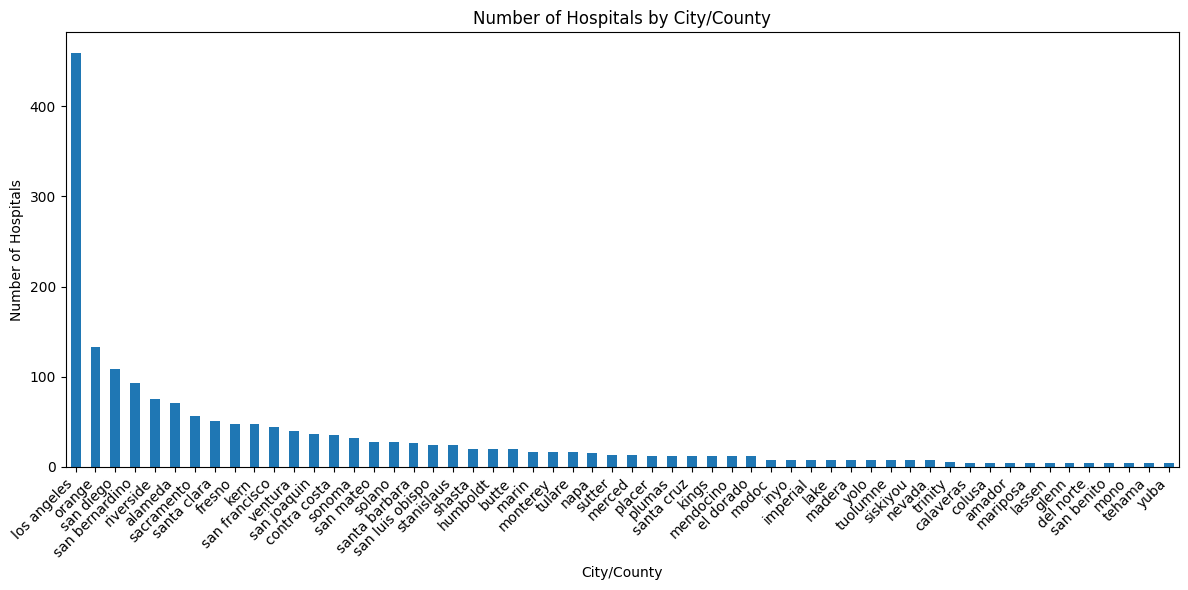

In [60]:
import matplotlib.pyplot as plt

# Summarize hospitals by city/county
city_counts = merged_df["county"].value_counts()
print("Number of hospitals per city/county:")
display(city_counts)

# Plot histogram of hospitals by city/county
plt.figure(figsize=(12,6))
city_counts.plot(kind='bar')
plt.title("Number of Hospitals by City/County")
plt.xlabel("City/County")
plt.ylabel("Number of Hospitals")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


It is not surprising that Los Angeles has far more hospitals than other cities in California.

Are there any hospitals closed between 2007 and 2010? I will look for hospitals that appear in one year's data but are missing in the subsequent year to identify closures.

In [50]:
closed_hospitals_by_year = {}

years_to_compare = [2007, 2008, 2009]

for year in years_to_compare:
    fac_no_current_year = set(merged_df[merged_df['year'] == year]['fac_no'].dropna().unique())

    fac_no_next_year = set(merged_df[merged_df['year'] == year + 1]['fac_no'].dropna().unique())

    # Identify hospitals present in current year but not in next year
    closed_fac_no = fac_no_current_year - fac_no_next_year

    transition_key = f"{year}-{year+1}"
    closed_hospitals_by_year[transition_key] = list(closed_fac_no)

print("Closed hospitals identified for each transition period:")
for transition, hospitals in closed_hospitals_by_year.items():
    print(f"  {transition}: {len(hospitals)} hospitals closed")

Closed hospitals identified for each transition period:
  2007-2008: 8 hospitals closed
  2008-2009: 2 hospitals closed
  2009-2010: 9 hospitals closed


Summarize the ownership of the closed hospitals:

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
df_data = []
for transition_key, summary in closure_summary.items():
    row = {'Transition Year': transition_key, 'Total Closures': summary['total_closures']}
    row.update(summary['control_type_distribution'])
    df_data.append(row)

closures_df = pd.DataFrame(df_data)
closures_df = closures_df.fillna(0)

control_types = []
for summary in closure_summary.values():
    control_types.extend(summary['control_type_distribution'].keys())
control_types = sorted(list(set(control_types)))

column_order = ['Transition Year', 'Total Closures'] + control_types
closures_df = closures_df[column_order]

print("\nHospital Closure Summary DataFrame:")
display(closures_df)


Hospital Closure Summary DataFrame:


,Transition Year,Total Closures,city/county,investor,non-profit,state
0,2007-2008,8,2.0,2,4,0.0
1,2008-2009,2,0.0,1,1,0.0
2,2009-2010,9,0.0,4,3,2.0


It looks that private hospitals(investor, non-profit) are more affected by the great recession than the public hospitals( state, city/county, district, university).

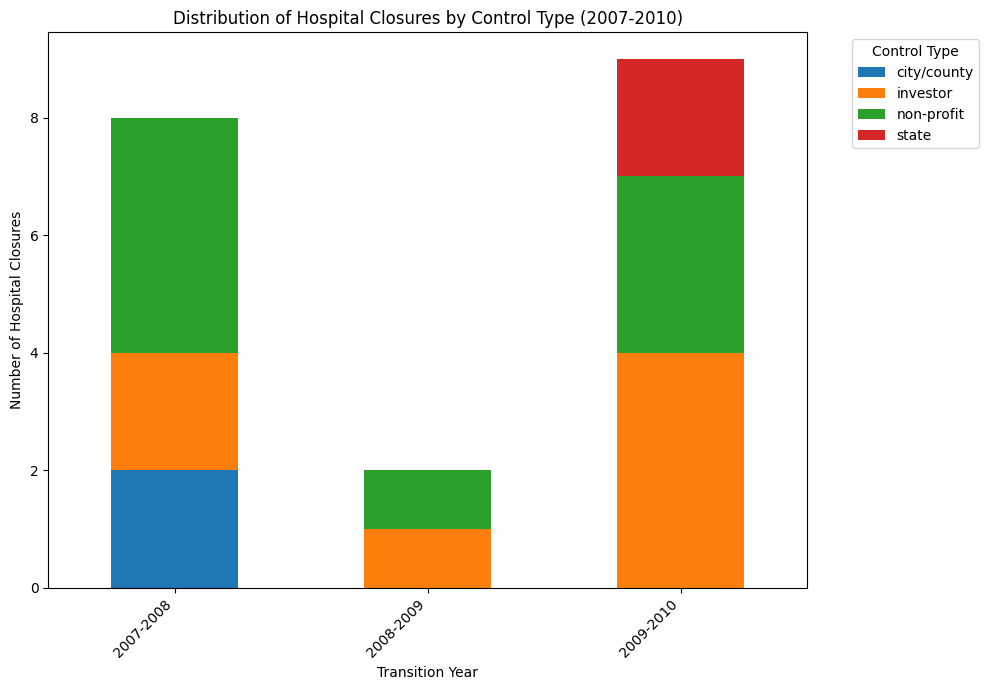

In [55]:
import matplotlib.pyplot as plt
plot_columns = [col for col in closures_df.columns if col not in ['Transition Year', 'Total Closures']]
closures_df.set_index('Transition Year')[plot_columns].plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Hospital Closures by Control Type (2007-2010)')
plt.xlabel('Transition Year')
plt.ylabel('Number of Hospital Closures')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Control Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [56]:
%%shell
ls "/content/drive/MyDrive/Colab Notebooks/milestone1CL .ipynb"

'/content/drive/MyDrive/Colab Notebooks/milestone1CL .ipynb'


In [65]:
%%shell

jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/milestone1CL .ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/milestone1CL .ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 573097 bytes to /content/drive/MyDrive/Colab Notebooks/milestone1CL .html
